# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2024-2025 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 21.4.2025

## Initialisation

In [27]:
%matplotlib inline 

In [28]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

/Users/mariomanzano/spyder_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mariomanzano/spyder_env/lib/python3.13/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [29]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

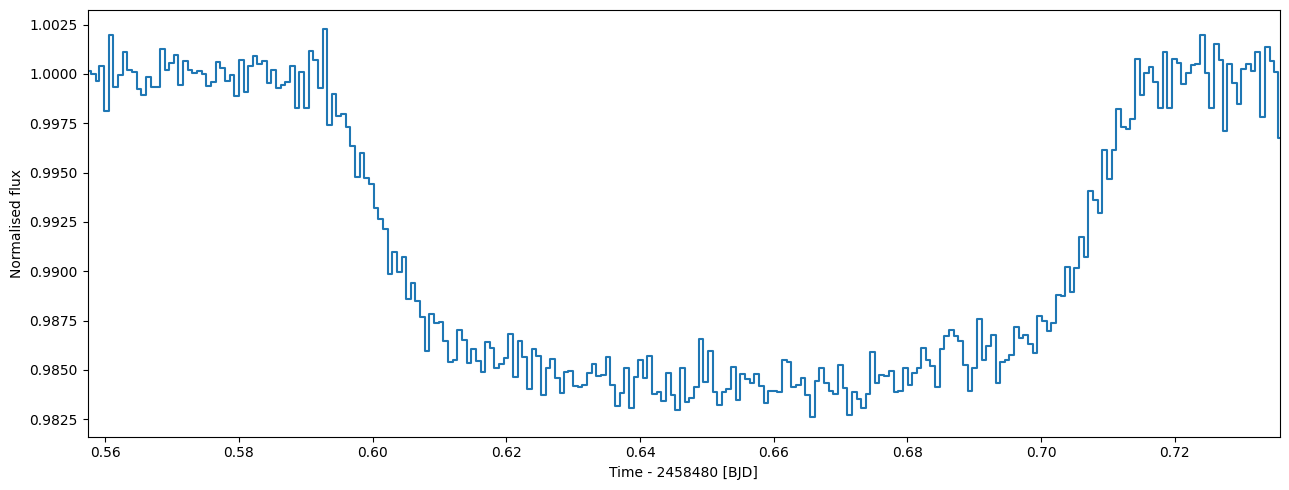

In [30]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [31]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [32]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [33]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

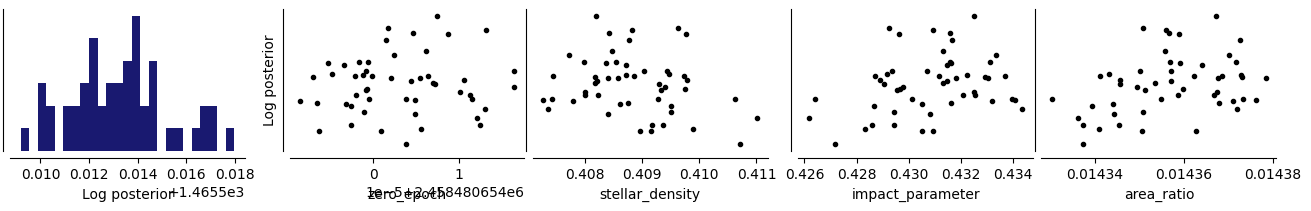

In [34]:
lpf.optimize_global(niter=500, npop=50)

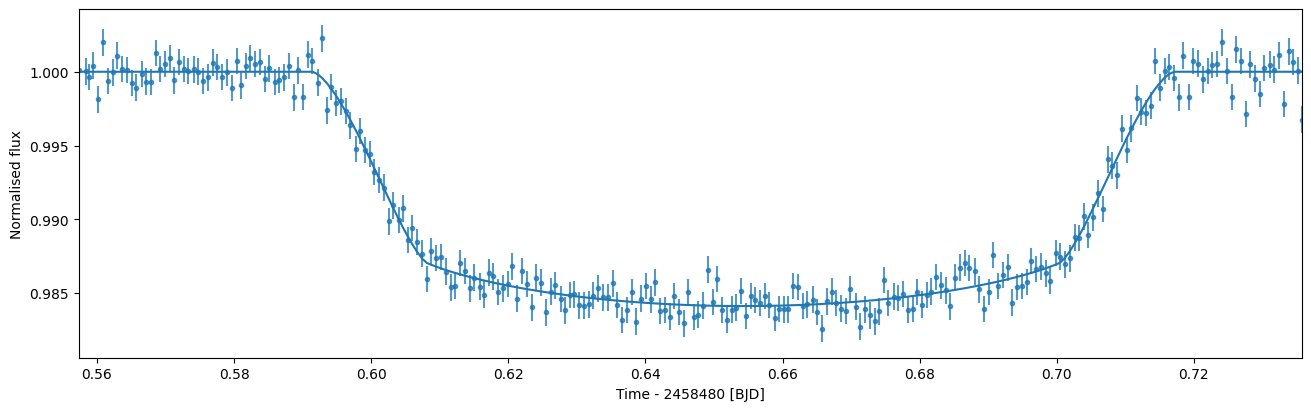

In [35]:
lpf.plot_light_curve();

In [36]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling: 100%|██████████| 2/2 [00:06<00:00,  3.38s/it]  


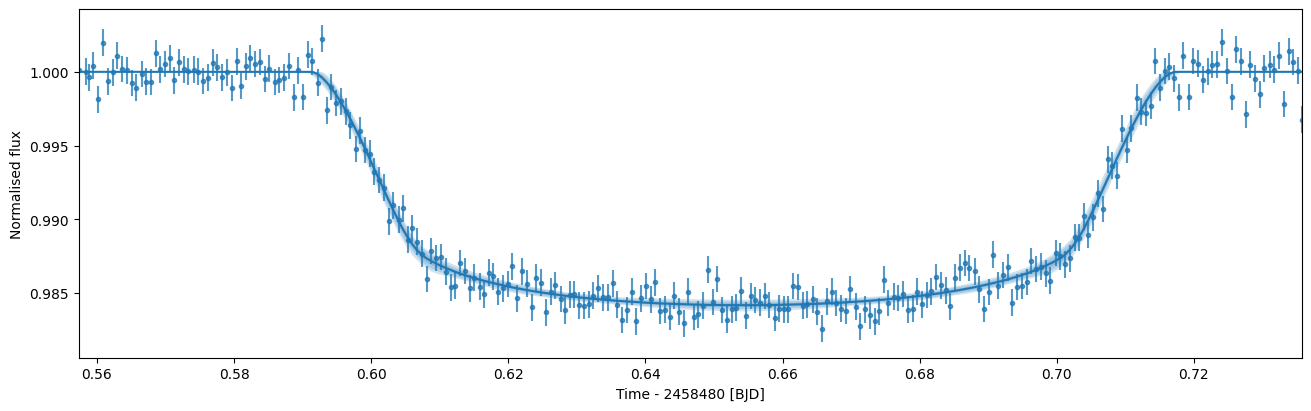

In [37]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

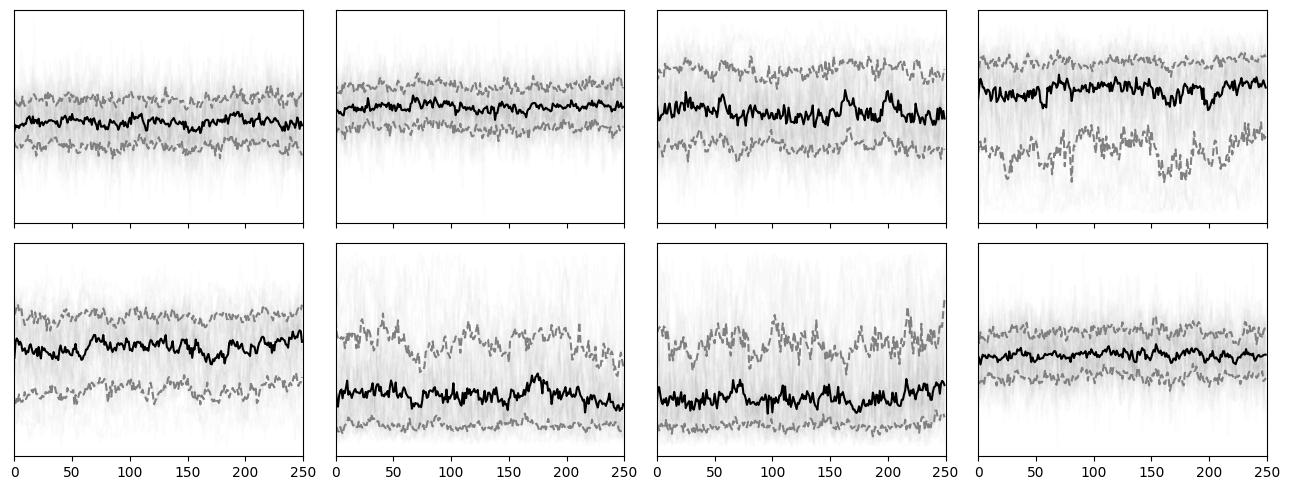

In [38]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [39]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [40]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

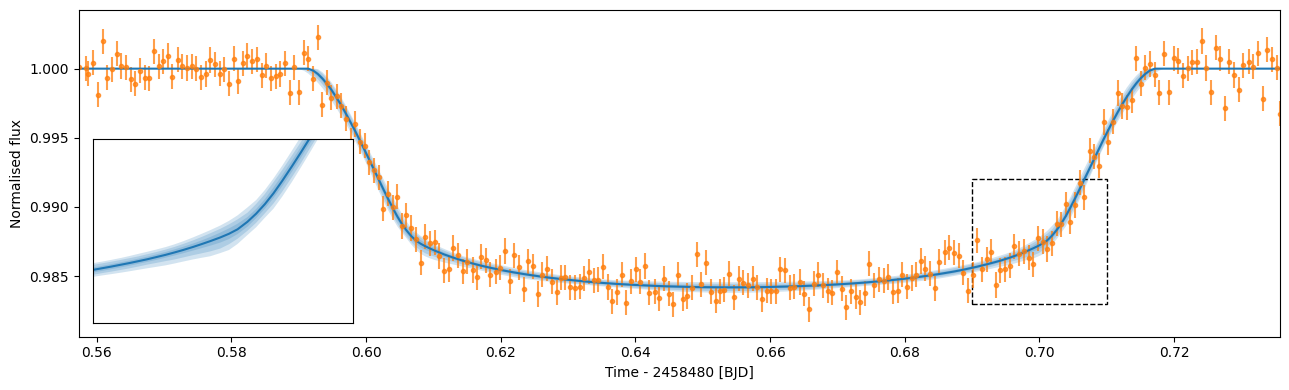

In [41]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [42]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4399,0.3175,0.0139,0.3481,3.0910e-01,-3.0409,0.1178,3.0237,1.4644,0.1258,0.0951
std,1.6316e-04,1.1128e-09,0.0352,0.1257,0.0005,0.2059,2.2100e-01,0.0191,0.0019,0.0808,0.0440,0.0010,0.0026
min,2.4585e+06,1.0914e+00,0.3387,0.0002,0.0126,0.0470,2.6410e-05,-3.1157,0.1125,2.7733,1.3715,0.1225,0.0874
25%,2.4585e+06,1.0914e+00,0.4130,0.2428,0.0135,0.1830,1.3889e-01,-3.0538,0.1163,2.9627,1.4309,0.1251,0.0931
50%,2.4585e+06,1.0914e+00,0.4374,0.3533,0.0139,0.3004,2.5007e-01,-3.0412,0.1180,3.0200,1.4535,0.1257,0.0948
75%,2.4585e+06,1.0914e+00,0.4679,0.4135,0.0142,0.4722,4.3480e-01,-3.0280,0.1193,3.0886,1.4923,0.1264,0.0971
max,2.4585e+06,1.0914e+00,0.5276,0.5529,0.0152,0.9998,9.9919e-01,-2.9579,0.1231,3.2148,1.5707,0.1295,0.1012


<Axes: >

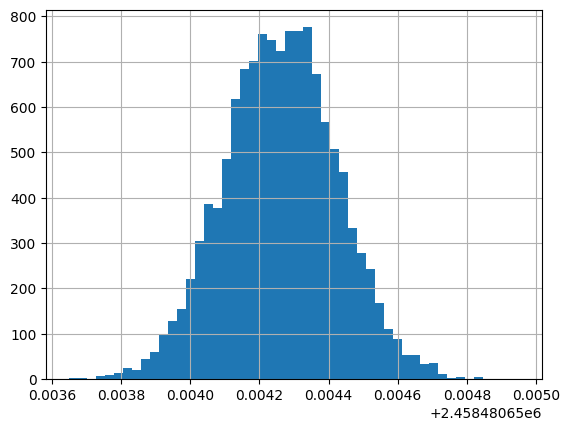

In [43]:
df.tc.hist(bins=50)

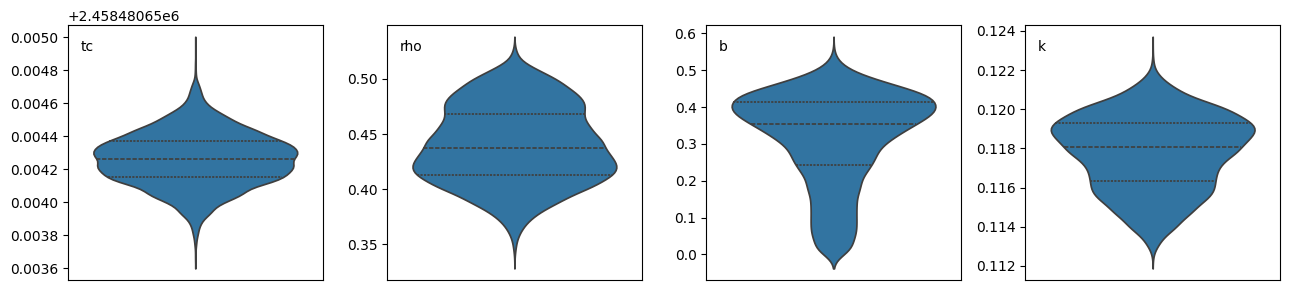

In [44]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

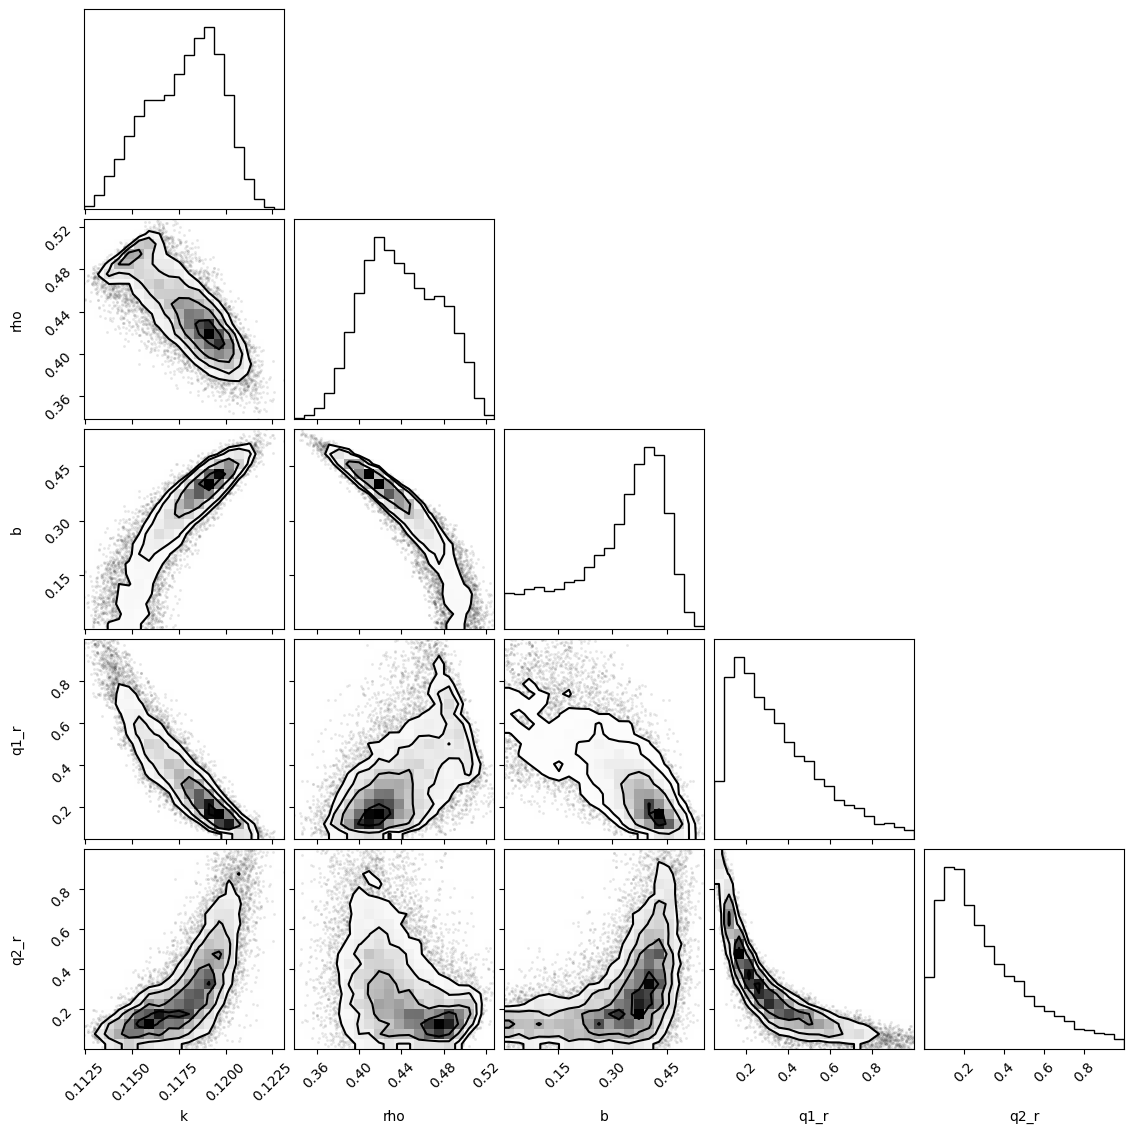

In [45]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

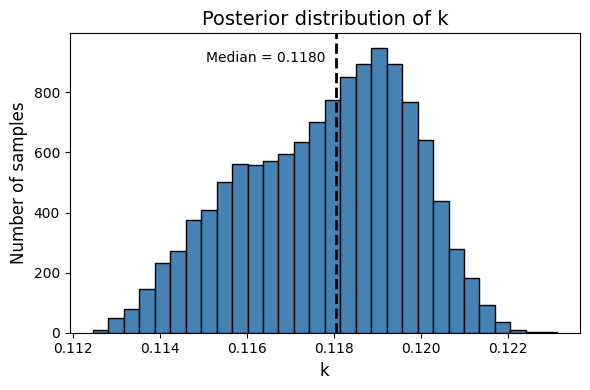

The median value of k is: 0.1180


In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming that the values of 'k' are in a DataFrame called 'df'
k_values = df['k']  # Extracting the 'k' values from the dataframe

# Create the histogram
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(k_values, bins=30, color='steelblue', edgecolor='black')

# Line to show the median
median_k = np.median(k_values)
ax.axvline(median_k, color='k', linestyle='dashed', linewidth=2)

# Set labels and title
ax.set_xlabel('k', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Posterior distribution of k', fontsize=14)

# Display the median value
ax.text(median_k - 0.0030,900, f'Median = {median_k:.4f}', color='k')

# Show the plot
plt.tight_layout()
plt.show()

# Print the median
print(f"The median value of k is: {median_k:.4f}")

In [57]:
# K median value:
k_median = 0.1180

# Star radius (approximate)
R_star = 1.66 * 6.96e8  # In meters # Reference: https://science.nasa.gov/exoplanet-catalog/wasp-12-b/

# Radius ratio (k)
k = 0.12  # This is just an example, replace it with the real value

# Calculate the planet's radius
R_p = k * R_star  # Planet radius in meters

# Convert the radius to Jupiter radii (1 Jupiter radius ≈ 7.1492e7 meters)
R_p_Jup = R_p / 7.1492e7

print(f"The estimated radius of the planet is approximately {R_p_Jup:.2f} Jupiter radii.")

The median value of k is: 0.1180
The estimated radius of the planet is approximately 1.94 Jupiter radii.


2. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

- Answer.



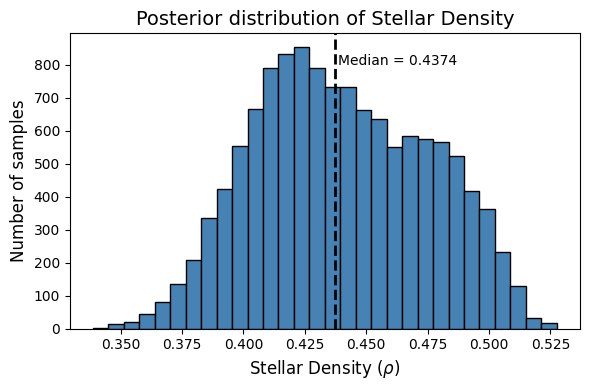

The median stellar density (rho) is: 0.4374


In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'rho' values are stored in the DataFrame 'df'
rho_values = df['rho']  # Extracting the 'rho' values from the dataframe

# Create the histogram
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(rho_values, bins=30, color='steelblue', edgecolor='black')

# Add a line to show the median
median_rho = np.median(rho_values)
ax.axvline(median_rho, color='k', linestyle='dashed', linewidth=2)

# Set labels and title
ax.set_xlabel('Stellar Density ($\\rho$)', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Posterior distribution of Stellar Density', fontsize=14)

# Display the median value
ax.text(median_rho + 0.001, 800, f'Median = {median_rho:.4f}', color='k')

# Show the plot
plt.tight_layout()
plt.show()

# Print the median
print(f"The median stellar density (rho) is: {median_rho:.4f}")

In [60]:
import numpy as np

# Rho median value:
rho_median = 0.4374

# Radio de la estrella (aproximado)
R_star = 1.66 * 6.96e8  # En metros, 1.55 veces el radio del Sol

# Masa de la estrella:
M_star = 1.35 * M_sun  # Masa de la estrella en kg (aproximadamente)

# Calcular la densidad teórica de la estrella (rho_theoretical)
rho_theoretical = (3 * M_star) / (4 * np.pi * R_star**3)

# Imprimir la densidad teórica
print(f"The theoretical stellar density is: {rho_theoretical:.2e} kg/m^3")

The theoretical stellar density is: 4.16e+02 kg/m^3


The estimated stellar density (ρ) from the transit modeling and the theoretical stellar density for a WASP-12-like star were compared. The median stellar density obtained from the posterior distribution of the transit modeling is 0.4374 $g/cm^3$ (or 437.4 $kg/m^3$). On the other hand, the theoretical stellar density, calculated using the star’s mass and radius, is 416 $kg/m^3$ The comparison reveals that the estimated density from the transit modeling is slightly higher than the theoretical value. However, the difference between the two densities is minimal, indicating that the stellar properties inferred from the transit modeling are in close agreement with the theoretical values for a WASP-12-like star.

3. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

The plot shows several pairs of parameters, and we can see that many of them have a clear correlation. For example, the parameters k and $\rho$ have a correlation, as shown by the elongated distribution in their scatter plot. Similarly, the correlations between $\rho$ and b, or k and q1_r, show how the values of one are related to the values of another.

In practice, these correlations suggest that the parameter space is not fully independent and that the values of certain parameters can provide information about others. This is important because correlated parameters could introduce degeneracies, making it harder to precisely determine the individual values of each parameter. For instance, a model might fit a range of parameters that are correlated in a way that leads to the same overall results, so it can be difficult to isolate the exact influence of each one.

In this context, it’s essential to take these correlations into account when fitting models and interpreting the results, as well as to ensure that proper priors are applied to avoid misinterpretations of the model’s predictions.


---
<center>&copy;2025 Hannu Parviainen</center>